In [1]:
import sys

import importlib
import numpy as np
import os

# Remontée de deux niveaux pour accéder à Data_loader
current_dir = os.getcwd()
project_root = os.path.normpath(os.path.join(current_dir, "..", ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Chemin du projet : {project_root}")

# Import du module de chargement des données
module_name = "RSA_deep_working.Data_loader.class_data_loaders"

try:
    class_data_loaders = importlib.import_module(module_name)
    DirectoryRSAClass = class_data_loaders.DirectoryRSAClass
except ModuleNotFoundError as e:
    print(f"Erreur lors de l'importation du module {module_name} : {e}")
    sys.exit(1)

Chemin du projet : /home/loai/Test/RSMLExtraction


In [2]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import rsml
import tifffile

from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass

# importing pretrained segmentation model
import segmentation_models_pytorch as smp
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="runs/uc1_segmentation")
global_step = 0


2025-04-04 15:29:40.151454: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 15:29:40.158043: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743773380.165907  716127 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743773380.168405  716127 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-04 15:29:40.177392: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

## Dataset and data loaders

In [3]:
base_directory = "/home/loai/Test/data/UC1_data/"

In [4]:
from RSA_deep_working.Data_loader.class_data_loaders import DirectoryRSAClass
import os
import numpy as np
import tifffile
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms

# Dimensions d'origine et calculs
H, W = (1166, 1348)

H_new, W_new = (1184, 1376)
padding_bottom, padding_right = H_new - H, W_new - W  # the opposite lol
print("pad :", padding_right, padding_bottom)

# Transformations pré-calculées
img_transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
    transforms.Normalize(mean=[0.5], std=[0.5])
])
mask_transform_series = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),

])
mask_transform_image = transforms.Compose([
    transforms.ToTensor(),

    #transforms.Resize((H_new, W_new), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.Pad(padding=(0, 0, padding_right, padding_bottom), fill=0),
])


def mtg_transform(mtg):
    """
    Transforme le MTG en un tenseur PyTorch.
    """
    # Convertir le MTG en une représentation adaptée
    # Par exemple, convertir les coordonnées en tenseur
    # ou appliquer d'autres transformations spécifiques
    return mtg

pad : 28 18


In [ ]:
# Optimisation de la lecture des TIFF : mise en cache par fichier
class CachedTiffReader:
    def __init__(self):
        self.cache = {}

    def get_page(self, img_path, key):
        if img_path not in self.cache:
            # Chargement unique du fichier, stockage de toutes les pages
            with tifffile.TiffFile(img_path) as tif:
                self.cache[img_path] = [page.asarray() for page in tif.pages]
        return self.cache[img_path][key]


tiff_reader = CachedTiffReader()


class RSASeg2DDataset(Dataset):
    def __init__(self, rsa_dir_loader, mode='series', img_transform=None,
                 mask_transform_series=None, mask_transform_image=None, image_with_mtg=False, as_RGB=False):
        """
        mode: 'series' pour charger l'ensemble de la série temporelle,
              'image' pour charger image par image.
        """
        self.mode = mode
        self.samples = []  # contiendra les tuples en fonction du mode
        self.img_transform = img_transform
        self.mask_transform_series = mask_transform_series
        self.mask_transform_image = mask_transform_image
        self.image_with_mtg = image_with_mtg
        self.as_RGB = as_RGB

        for loader in rsa_dir_loader.loaders:
            img_path = loader.image_stack_path
            mask_path = loader.date_map_path
            mtg_path = loader.rsml_default_file if os.path.exists(loader.rsml_default_file) else loader.rsml_expert_file

            # Lecture du nombre de slices dans la série
            with tifffile.TiffFile(img_path) as tif:
                num_slices = len(tif.pages)

            if mode == 'series':
                # Une entrée par série temporelle complète, on stocke num_slices
                self.samples.append((img_path, mask_path, num_slices, mtg_path))
            elif mode == 'image':
                # Une entrée par image (slice)
                for z in range(num_slices):
                    self.samples.append((img_path, mask_path, z, mtg_path))
            else:
                raise ValueError("Mode non reconnu, choisissez 'series' ou 'image'")

    def __len__(self):
        return len(self.samples)

    def num_times(self, idx):
        """
        Retourne le nombre de slices (temps) que comporte la série.
        """
        img_path, _, _, _ = self.samples[idx]
        with tifffile.TiffFile(img_path) as tif:
            num_slices = len(tif.pages)
        return num_slices

    def __getitem__(self, idx):
        # Extraction des informations de l'échantillon
        img_path, mask_path, slice_info, mtg_path = self.samples[idx]

        if self.mode == 'series':
            # Mode série : chargement complet de la série d'images
            img = tifffile.imread(img_path)
            mask_raw = tifffile.imread(mask_path)
            extra_info = slice_info  # ici, slice_info correspond à num_slices

            if self.img_transform:
                img = self.img_transform(img)
            # Appliquer la transformation du masque ou utiliser le masque brut
            mask = self.mask_transform_series(mask_raw) if self.mask_transform_series else mask_raw

        else:  # mode 'image'
            # Mode image : slice_info correspond à l'index de la slice (z)
            z = slice_info
            img = tiff_reader.get_page(img_path, z)
            mask_raw = tifffile.imread(mask_path)
            extra_info = z

            # Calcul vectorisé du masque : les pixels non nuls et <= z valent 1, sinon 0
            mask = np.where((mask_raw != 0) & (mask_raw <= z + 1), 1, 0)

            if self.img_transform:
                img = self.img_transform(img)
            mask = self.mask_transform_image(mask) if self.mask_transform_image else mask

        if (self.as_RGB):
            img = img.repeat(3, 1, 1)
        # Gestion du retour : si image_with_mtg est activé, on retourne mtg_path, sinon un tensor nul
        additional = mtg_path if self.image_with_mtg else torch.tensor(0)
        #mask to float64 
        mask = mask.float()
        return img, mask, extra_info, additional


In [6]:

dir_loader = DirectoryRSAClass(base_directory, load_date_map=True, lazy=True)

# Pour entraîner image par image :
rsa_dataset_image = RSASeg2DDataset(
    dir_loader,
    mode='image',
    img_transform=img_transform,
    mask_transform_image=mask_transform_image,  # pipeline dédié
    image_with_mtg=True
)

print("Nombre d'échantillons :", len(rsa_dataset_image), "images\n")

# for reproducibility
torch.manual_seed(42)
np.random.seed(42)

generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = torch.utils.data.random_split(
    rsa_dataset_image,
    [int(len(rsa_dataset_image) * 0.7), int(len(rsa_dataset_image) * 0.2),
     int(len(rsa_dataset_image) * 0.1) + 2],
    generator=generator
)

# Affichage des tailles des ensembles
print("Ensemble d'entraînement (image) :", len(train_set))
print("Ensemble de validation (image) :", len(val_set))
print("Ensemble de test (image) :", len(test_set))

Nombre d'échantillons : 754 images

Ensemble d'entraînement (image) : 527
Ensemble de validation (image) : 150
Ensemble de test (image) : 77


### 2D Image loaders

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation du device : {device}")

BATCH_SIZE = 8
# data loader optimization
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=8,
                                           pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=8,
                                          pin_memory=True)

Utilisation du device : cuda


Taille du batch : torch.Size([8, 1, 1184, 1376])
Taille du masque : torch.Size([8, 1, 1184, 1376])
Image : torch.Size([8, 1, 1184, 1376])
Masque : torch.Size([8, 1, 1184, 1376])


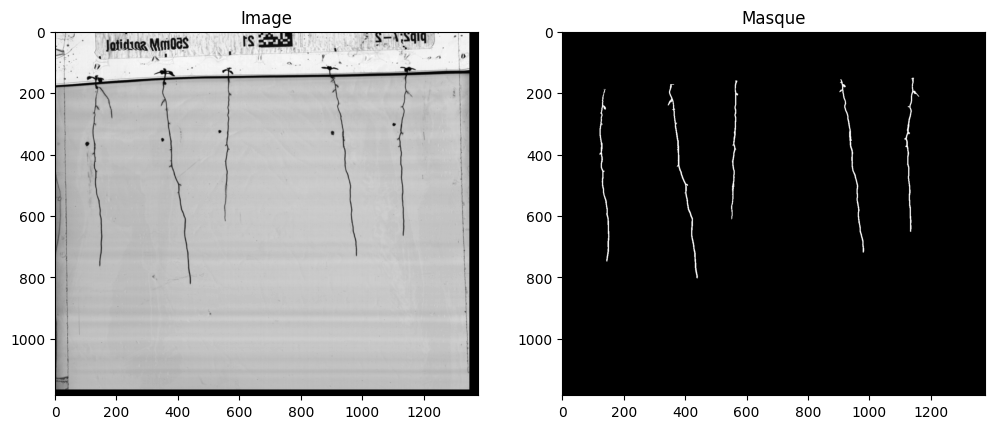

In [8]:
# plot example
batch = next(iter(train_loader))
print("Taille du batch :", batch[0].shape)
print("Taille du masque :", batch[1].shape)
img, mask, _, _ = batch
print("Image :", img.shape)
print("Masque :", mask.shape)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img[0, 0].cpu(), cmap='gray')
ax[0].set_title("Image")
ax[1].imshow(mask[0, 0].cpu(), cmap='gray')
ax[1].set_title("Masque")
plt.show()

## Evaluation

In [ ]:
import io
import torchvision.transforms.functional as TF


def tensor_to_heatmap_image(tensor, cmap='hot'):
    """
    Convertit un tableau numpy 2D en image heatmap.
    """
    plt.figure()
    plt.imshow(tensor, cmap=cmap)
    plt.axis('off')
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    plt.close()
    buf.seek(0)
    image = Image.open(buf)
    image = image.convert("RGB")
    return image

In [ ]:
def evaluate_segmentation(model, image, mask, mtg, metrics: list, prediction=None, threshold=0.5, writer=None,
                          global_step=None, device='cpu'):
    model.eval()
    image = image.to(device)
    mask = mask.to(device)

    # Calcul de la prédiction si non fournie
    if prediction is None:
        with torch.no_grad():
            output = model(image)
            # Supposons que le modèle renvoie des logits : on applique une sigmoïde
            pred = torch.sigmoid(output)
            # Binarisation (seuil à 0.5)
            prediction = (pred > threshold).float()

    # Calcul des métriques
    scores = {}
    for metric in metrics:
        scores[metric.__name__] = metric(prediction, mask, mtg)

    # Log des résultats dans TensorBoard si le SummaryWriter est fourni
    if writer is not None and global_step is not None:
        for metric_name, score in scores.items():
            writer.add_scalar(f"Eval/{metric_name}", score, global_step)

    # Retourne un dictionnaire de résultats
    return {
        'prediction': prediction,
        'scores': scores
    }


def evaluate_segmentation_on_loader(model, loader, metrics: list, threshold=0.5, writer=None, global_step=None,
                                    device='cpu'):
    """
    Évalue le modèle sur un DataLoader donné et log les heatmaps pour l'output et la sigmoid.
    """
    model.eval()
    all_scores = []
    all_predictions = []
    all_masks = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluation iteration", position=1, leave=False, dynamic_ncols=True):
            images, masks, time, mtgs = batch
            images = images.to(device)
            masks = masks.to(device)

            # Calcul de l'output et de la prédiction
            output = model(images)
            pred = torch.sigmoid(output)
            prediction = (pred > threshold).float()

            # Calcul des métriques
            scores = {}
            for metric in metrics:
                scores[metric.__name__] = metric(prediction.squeeze(1), masks.squeeze(1), time, mtgs[0])
            all_scores.append(scores)
            all_predictions.append(prediction.cpu())
            all_masks.append(masks.cpu())

            # Log dans TensorBoard si le writer est fourni
            if writer is not None and global_step is not None:
                # Log classique des images, masques et prédictions
                for metric in metrics:
                    avg_score = np.mean([score[metric.__name__] for score in all_scores])
                    writer.add_scalar(f"Eval/{metric.__name__}", avg_score, global_step)
                writer.add_images("Eval/Images", images[:5], global_step)
                writer.add_images("Eval/Predictions", prediction[:5], global_step)
                writer.add_images("Eval/Masks", masks[:5], global_step)

                # Création et log des heatmaps pour l'output et la sigmoid (pour les 5 premières images)
                output_heatmaps = []
                sigmoid_heatmaps = []
                for i in range(min(5, output.size(0))):
                    # Supposons que l'output et la sigmoid sont des cartes 2D (dimension [1, H, W])
                    out_np = output[i, 0].cpu().numpy()
                    sig_np = pred[i, 0].cpu().numpy()

                    # Création de l'image heatmap
                    out_img = tensor_to_heatmap_image(out_np, cmap='hot')
                    sig_img = tensor_to_heatmap_image(sig_np, cmap='hot')

                    # Conversion en tensor
                    out_tensor = TF.to_tensor(out_img)
                    sig_tensor = TF.to_tensor(sig_img)
                    output_heatmaps.append(out_tensor)
                    sigmoid_heatmaps.append(sig_tensor)

                output_heatmaps_tensor = torch.stack(output_heatmaps)
                sigmoid_heatmaps_tensor = torch.stack(sigmoid_heatmaps)

                writer.add_images("Eval/Output_Heatmap", output_heatmaps_tensor, global_step)
                writer.add_images("Eval/Sigmoid_Heatmap", sigmoid_heatmaps_tensor, global_step)

                writer.flush()
                global_step += 1
    torch.cuda.empty_cache()
    return {
        'scores': all_scores,
        'predictions': torch.cat(all_predictions),
        'masks': torch.cat(all_masks)
    }

In [10]:
import RSA_deep_working.Metrics.simple_metrics as sm
import RSA_deep_working.Metrics.topo_explicit_metrics as tm

metrics = sm.all_metrics()
tubular_metrics = tm.all_metrics()
print("Métriques disponibles :")
for metric in metrics:
    print(f"- {metric.__name__}")

print("Métriques tubulaires disponibles :")
for metric in tubular_metrics:
    print(f"- {metric.__name__}")

all_metrics = []
for metric in metrics:
    all_metrics.append(metric)
for metric in tubular_metrics:
    all_metrics.append(metric)

Métriques disponibles :
- dice
- f1_score
- iou
- pixel_accuracy
- precision
- recall
- specificity
- connectivity_metric
- ARI_index
- VI_index
- ARE_error
- betti_0_difference
- euler_charac_difference
Métriques tubulaires disponibles :
- cldice
- skeleton_recall
- Connectivity_Preserving_Instance_Segmentation
- evaluate_sk_seg


## Model

In [11]:
model_pretrained = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,  # "imagenet",
    in_channels=1,
    classes=1
)

# loading pretrained weights
#model_pretrained.load_state_dict(torch.load("/home/loai/Test/RSMLExtraction/RSA_deep_working/Existing_models/model_BCE_100epoch.pth"))
# test des deux modèles selon chaques metriques 
model_pretrained.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:


# Evaluation sur l'ensemble de validation
print("Evaluation du modèle pré-entraîné sur l'ensemble de validation")
results_pretrained = evaluate_segmentation_on_loader(
    model_pretrained,
    val_loader,
    metrics=all_metrics,
    threshold=0.5,
    writer=writer,
    global_step=global_step,
    device=device
)
print("Résultats du modèle pré-entraîné :")
for metric_name, score in results_pretrained['scores'][0].items():
    print(f"{metric_name}: {score:.4f}")

# empty cache and free memory
torch.cuda.empty_cache()
del model_pretrained
del results_pretrained

Evaluation du modèle pré-entraîné sur l'ensemble de validation


Evaluation iteration:   0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [12]:
#plot an prediction 
def plot_prediction(image, mask, prediction):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image.squeeze(0).cpu(), cmap='gray')
    ax[0].set_title("Image")
    ax[1].imshow(mask.squeeze(0).cpu(), cmap='gray')
    ax[1].set_title("Masque")
    ax[2].imshow(prediction.squeeze(0).cpu(), cmap='gray')
    ax[2].set_title("Prédiction")
    plt.show()


# plot a random image from the validation set
import random

idx = random.randint(0, len(val_set) - 1)
image, mask, time, mtg = val_set[idx]
plot_prediction(image, mask, results_pretrained['predictions'][idx])

NameError: name 'results_pretrained' is not defined

## Training

In [12]:
# Train the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, device='cpu', writer=None):
    torch.cuda.empty_cache()
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", position=0, leave=True,
                          dynamic_ncols=True):
            images, masks, _, _ = batch
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        #print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")
        torch.cuda.empty_cache()

        # Log the loss to TensorBoard
        if writer is not None:
            writer.add_scalar("Loss/train", epoch_loss, epoch)

        # Evaluation on validation set
        if val_loader is not None:
            evaluate_segmentation_on_loader(
                model,
                val_loader,
                metrics=all_metrics,
                threshold=0.5,
                writer=writer,
                global_step=epoch,
                device=device
            )
        torch.cuda.empty_cache()

    return model

In [13]:
# cuda - clear cache
torch.cuda.empty_cache()

In [14]:
# Define the model, loss function, and optimizer - DICE
loss_fn = smp.losses.DiceLoss(
    mode='binary')
optimizer = optim.Adam(model_pretrained.parameters(), lr=5e-5)

# Train the model
model_trained = train_model(
    model_pretrained,
    train_loader,
    val_loader,
    criterion=loss_fn,
    optimizer=optimizer,
    num_epochs=100,
    device=device,
    writer=writer
)

Epoch 1/100:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/66 [00:00<?, ?it/s]

...

Epoch 25/100:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Epoch 26/100:   0%|          | 0/66 [00:00<?, ?it/s]

Evaluation iteration:   0%|          | 0/19 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# save the model
torch.save(model_trained.state_dict(), "model_DICE_100epoch.pth")